In [1]:
# ============================================================
# PHASE 14C — RECOVER REAL K3/K4/BASIC FEATURE NAMES
# ============================================================
# Goal:
# Recover the real handcrafted genomic feature names used in the
# K3/K4/Basic representation, instead of generic genomic_feature_x.
#
# Why:
# Phase 14 and 14B found only generic feature names.
# However, earlier output shows files containing real names such as:
# k4_GTAG, k4_GGTA, k4_ACCA...
#
# This phase:
# 1. Searches files deeply for k3_/k4_/GC/CpG/skew names.
# 2. Loads possible feature-name lists from CSV/TXT/JSON/PKL/JOBLIB.
# 3. Rejects generic genomic_feature_x mappings.
# 4. Attempts to identify a full 356-feature mapping.
# 5. If unavailable, reconstructs plausible feature orders.
# 6. Uses available top-feature files to infer which order is likely.
# 7. Remaps Phase 14 permutation and SHAP results.
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import itertools
import json
import pickle
import joblib
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_colwidth", 500)

import os
from pathlib import Path
import pandas as pd
from google.colab import drive

try:
    drive.mount('/content/drive')
except ValueError:
    print("Drive đã được kết nối từ trước.")

PROJECT_DIR = Path("/content/drive/MyDrive/Project_Protein")

PHASE14_DIR = PROJECT_DIR / "model" / "phase14_explainability_analysis"
PHASE14_RESULT_DIR = PHASE14_DIR / "results"

PHASE14C_DIR = PROJECT_DIR / "model" / "phase14c_recover_real_genomic_feature_names"
RESULT_DIR = PHASE14C_DIR / "results"
FIGURE_DIR = PHASE14C_DIR / "figures"
EXCEL_DIR = PHASE14C_DIR / "excel"
REPORT_DIR = PHASE14C_DIR / "reports"

for d in [PHASE14C_DIR, RESULT_DIR, FIGURE_DIR, EXCEL_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

EXPECTED_N = 356
RANDOM_SEED = 42

print("Phase 14C output:", PHASE14C_DIR)

Mounted at /content/drive
Phase 14C output: /content/drive/MyDrive/Project_Protein/model/phase14c_recover_real_genomic_feature_names


In [2]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def save_df(df, path):
    path = Path(path)
    df.to_csv(path, index=False)
    print("Saved:", path)


def round_numeric_columns(df, digits=6):
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            df[col] = df[col].round(digits)
    return df


def generate_kmers(k):
    return ["".join(p) for p in itertools.product("ACGT", repeat=k)]


def is_generic_feature_name(x):
    x = str(x).strip().lower()
    return bool(re.fullmatch(r"genomic_feature_\d+", x)) or bool(re.fullmatch(r"feature_\d+", x))


def has_real_genomic_signal_name(x):
    """
    Detect whether a feature name looks like a real handcrafted genomic feature.
    """
    s = str(x).strip()
    sl = s.lower()

    if is_generic_feature_name(sl):
        return False

    patterns = [
        r"^k3[_:\-][acgtACGT]{3}$",
        r"^k4[_:\-][acgtACGT]{4}$",
        r"^3mer[_:\-][acgtACGT]{3}$",
        r"^4mer[_:\-][acgtACGT]{4}$",
        r"^kmer3[_:\-][acgtACGT]{3}$",
        r"^kmer4[_:\-][acgtACGT]{4}$",
        r"^[acgtACGT]{3}$",
        r"^[acgtACGT]{4}$",
    ]

    for p in patterns:
        if re.match(p, s):
            return True

    keywords = [
        "gc", "cpg", "skew", "at_content", "gc_content",
        "a_content", "c_content", "g_content", "t_content",
        "cpg_ratio", "observed_expected", "oe",
        "nucleotide", "seq_length", "length"
    ]

    return any(k in sl for k in keywords)


def detect_feature_name_column(df):
    candidates = [
        "feature_name", "feature", "features", "name", "column",
        "column_name", "variable", "var", "Feature", "Feature_Name",
        "selected_features", "selected_feature"
    ]

    for c in candidates:
        if c in df.columns:
            return c

    if df.shape[1] == 1:
        return df.columns[0]

    # Prefer object columns with real feature-name-like values
    object_cols = [c for c in df.columns if df[c].dtype == "object"]
    best_col = None
    best_score = -1

    for c in object_cols:
        vals = df[c].dropna().astype(str).head(500).tolist()
        score = sum(has_real_genomic_signal_name(v) for v in vals)
        if score > best_score:
            best_score = score
            best_col = c

    return best_col


def infer_feature_group(feature_name):
    f = str(feature_name).strip()
    fl = f.lower()

    if is_generic_feature_name(fl):
        return "Generic_unmapped"

    if re.match(r"^k3[_:\-][acgt]{3}$", fl) or re.match(r"^3mer[_:\-][acgt]{3}$", fl) or re.match(r"^kmer3[_:\-][acgt]{3}$", fl):
        return "K3_kmer"
    if re.match(r"^k4[_:\-][acgt]{4}$", fl) or re.match(r"^4mer[_:\-][acgt]{4}$", fl) or re.match(r"^kmer4[_:\-][acgt]{4}$", fl):
        return "K4_kmer"

    fu = f.upper()
    if len(fu) == 3 and set(fu).issubset(set("ACGT")):
        return "K3_kmer"
    if len(fu) == 4 and set(fu).issubset(set("ACGT")):
        return "K4_kmer"

    if "cpg" in fl or "observed_expected" in fl or "oe_cpg" in fl or "cpg_oe" in fl:
        return "CpG_related"

    if "gc" in fl:
        return "GC_content"

    if "skew" in fl:
        return "Skew"

    if fl in ["a", "c", "g", "t", "a_content", "c_content", "g_content", "t_content",
              "freq_a", "freq_c", "freq_g", "freq_t"]:
        return "Nucleotide_composition"

    if "length" in fl:
        return "Sequence_length"

    return "Other_basic"


def clean_feature_names(names):
    cleaned = []
    for x in names:
        if pd.isna(x):
            continue
        s = str(x).strip()
        if s == "" or s.lower() == "nan":
            continue
        cleaned.append(s)
    return cleaned


def summarize_feature_list(names):
    names = clean_feature_names(names)
    n = len(names)
    n_generic = sum(is_generic_feature_name(x) for x in names)
    n_real = sum(has_real_genomic_signal_name(x) for x in names)
    groups = pd.Series([infer_feature_group(x) for x in names]).value_counts().to_dict() if n > 0 else {}
    return {
        "n_names": n,
        "n_generic": n_generic,
        "n_real_like": n_real,
        "real_like_ratio": n_real / n if n else 0,
        "generic_ratio": n_generic / n if n else 0,
        "groups": groups,
        "preview": names[:15]
    }


def validate_full_real_mapping(names, expected_n=356):
    names = clean_feature_names(names)
    if len(names) != expected_n:
        return False
    n_generic = sum(is_generic_feature_name(x) for x in names)
    n_real = sum(has_real_genomic_signal_name(x) for x in names)
    return n_generic == 0 and n_real >= 300

In [3]:
# ============================================================
# DEEP SEARCH FOR REAL FEATURE NAMES IN TEXT-LIKE FILES
# ============================================================

text_patterns = ["*.csv", "*.txt", "*.json", "*.tsv"]

candidate_records = []

for pattern in text_patterns:
    files = sorted(PROJECT_DIR.rglob(pattern))

    for path in files:
        try:
            # Skip huge files > 100 MB
            if path.stat().st_size > 100 * 1024 * 1024:
                continue

            text_sample = path.read_text(errors="ignore")[:300000]

            # Search for real feature-name clues
            clue_count = 0
            clue_count += len(re.findall(r"k3[_:\-][ACGTacgt]{3}", text_sample))
            clue_count += len(re.findall(r"k4[_:\-][ACGTacgt]{4}", text_sample))
            clue_count += len(re.findall(r"3mer[_:\-][ACGTacgt]{3}", text_sample))
            clue_count += len(re.findall(r"4mer[_:\-][ACGTacgt]{4}", text_sample))
            clue_count += len(re.findall(r"GC_content|CpG|cpg|skew", text_sample))

            if clue_count > 0:
                candidate_records.append({
                    "path": str(path),
                    "suffix": path.suffix,
                    "size_kb": round(path.stat().st_size / 1024, 2),
                    "clue_count": clue_count,
                    "sample": text_sample[:500].replace("\n", " ")[:500]
                })

        except Exception:
            pass

deep_text_candidates_df = pd.DataFrame(candidate_records)

if deep_text_candidates_df.empty:
    print("No text-like files with real feature-name clues found.")
else:
    deep_text_candidates_df = deep_text_candidates_df.sort_values(
        ["clue_count", "size_kb"],
        ascending=[False, True]
    ).reset_index(drop=True)

    display(deep_text_candidates_df.head(50))

save_df(
    deep_text_candidates_df,
    RESULT_DIR / "phase14c_deep_text_feature_name_candidates.csv"
)

,path,suffix,size_kb,clue_count,sample
0,/content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/phase3_0_feature_names_v1.json,.json,67.61,684,"{ ""n_protein_features"": 1024, ""n_genomic_features"": 356, ""n_combined_features"": 1380, ""protein_feature_names"": [ ""protbert_sw_0"", ""protbert_sw_1"", ""protbert_sw_2"", ""protbert_sw_3"", ""protbert_sw_4"", ""protbert_sw_5"", ""protbert_sw_6"", ""protbert_sw_7"", ""protbert_sw_8"", ""protbert_sw_9"", ""protbert_sw_10"", ""protbert_sw_11"", ""protbert_sw_12"", ""protbert_sw_13"", ""prot..."
1,/content/drive/MyDrive/Project_Protein/model/phase2_2_genomic_analysis/results/phase2_2_random_forest_feature_importance.csv,.csv,10.45,342,"feature,importance k4_TGAG,0.015787169436277018 k4_AAGG,0.012512027614551 k4_CCCC,0.011546060611813586 GC_content_bin_08,0.011129794755988475 k4_CTGT,0.009442760656653646 k4_CGCT,0.007479500068918094 k3_TAG,0.007210608569194112 k4_GATC,0.006885416539039482 k4_AGTG,0.0068374918738333505 k4_CTTT,0.006661017514477441 k4_GTAG,0.006525332823638728 k4_CTCC,0.006467726048933097 k4_TCAG,0.0063855886706444785 k4_CTCA,0.006312376417510694 k3_GTA,0.006262440279197772 k3_CTG,0.005848521778040071 k3_CCC,..."
2,/content/drive/MyDrive/Project_Protein/model/phase2_2_genomic_analysis/results/phase2_2_logistic_regression_coefficients.csv,.csv,17.77,342,"feature,coefficient,abs_coefficient k4_CTGT,-0.03860162329009309,0.03860162329009309 k4_CCGT,-0.03494008075956582,0.03494008075956582 k4_ATCC,-0.03460357039883062,0.03460357039883062 k4_AAGG,0.03355827946287708,0.03355827946287708 k4_GATC,-0.030320488554606412,0.030320488554606412 k4_GTAG,-0.03007903787838481,0.03007903787838481 k4_AAAG,0.029626573867093782,0.029626573867093782 k4_TGAG,-0.029322006084515257,0.029322006084515257 k4_AACC,-0.028586672077077473,0.028586672077077473 k4_TCTG,-0.02..."
3,/content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_2_error_modality_contribution/results/phase3_2C_combined_logistic_regression_coefficients.csv,.csv,87.44,342,"feature,coefficient,abs_coefficient,modality k4_GTAG,-0.03648944404573647,0.03648944404573647,genomic protbert_sw_40,-0.031692694461528774,0.031692694461528774,protein protbert_sw_418,-0.029147957667666702,0.029147957667666702,protein protbert_sw_822,0.027778686926175182,0.027778686926175182,protein k4_GGTA,-0.027391249076618055,0.027391249076618055,genomic k4_ACCA,-0.026826950416710817,0.026826950416710817,genomic k4_TCTG,-0.02639367870129794,0.02639367870129794,genomic protbert_sw_160,-0.0..."
4,/content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_val_genomic_k3k4basic_v1.csv,.csv,1643.83,342,"seq_length,A_count,C_count,G_count,T_count,A_frac,C_frac,G_frac,T_frac,GC_count,AT_count,GC_content,AT_content,CpG_count,CpG_density,CpG_observed_expected,GC_skew,AT_skew,purine_frac_AG,pyrimidine_frac_CT,GC_content_bin_01,GC_content_bin_02,GC_content_bin_03,GC_content_bin_04,GC_content_bin_05,GC_content_bin_06,GC_content_bin_07,GC_content_bin_08,GC_content_bin_09,GC_content_bin_10,GC_content_upstream_2kb,GC_content_downstream_500bp,GC_content_tss_near_500bp,CpG_count_upstream_2kb,CpG_count_..."
5,/content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/features/X_test_genomic_k3k4basic_v1.csv,.csv,1648.95,342,"seq_length,A_count,C_count,G_count,T_count,A_frac,C_frac,G_frac,T_frac,GC_count,AT_count,GC_content,AT_content,CpG_count,CpG_density,CpG_observed_expected,GC_skew,AT_skew,purine_frac_AG,pyrimidine_frac_CT,GC_content_bin_01,GC_content_bin_02,GC_content_bin_03,GC_content_bin_04,GC_content_bin_05,GC_content_bin_06,GC_content_bin_07,GC_content_bin_08,GC_content_bin_09,GC_content_bin_10,GC_content_upstream_2kb,GC_content_downstream_500bp,GC_content_tss_near_500bp,CpG_count_upstream_2kb,CpG_count_..."
6,/content/drive/MyDrive/Project_Protein/model/phase2_genomic_regulatory_baseline/features/X_val_k3_k4_plus_basic_v1.csv,.csv,1843.78,342,"seq_length,A_count,C_count,G_c

Saved: /content/drive/MyDrive/Project_Protein/model/phase14c_recover_real_genomic_feature_names/results/phase14c_deep_text_feature_name_candidates.csv


In [4]:
# ============================================================
# EXTRACT FEATURE NAME COLUMNS FROM CSV/TSV CANDIDATES
# ============================================================

csv_candidate_records = []
possible_feature_lists = []

csv_paths = []
if not deep_text_candidates_df.empty:
    csv_paths = [
        Path(p) for p in deep_text_candidates_df["path"].tolist()
        if Path(p).suffix.lower() in [".csv", ".tsv"]
    ]

for path in csv_paths:
    try:
        sep = "\t" if path.suffix.lower() == ".tsv" else ","
        df = pd.read_csv(path, sep=sep)

        col = detect_feature_name_column(df)
        if col is None:
            continue

        names = clean_feature_names(df[col].tolist())
        summary = summarize_feature_list(names)

        rec = {
            "path": str(path),
            "shape": str(df.shape),
            "column_used": col,
            **{k: v for k, v in summary.items() if k not in ["groups", "preview"]},
            "groups": json.dumps(summary["groups"]),
            "preview": "; ".join(summary["preview"])
        }
        csv_candidate_records.append(rec)

        if summary["n_real_like"] > 0:
            possible_feature_lists.append({
                "source_type": "csv_column",
                "path": str(path),
                "column": col,
                "names": names,
                "summary": summary
            })

    except Exception as e:
        pass

csv_feature_candidates_df = pd.DataFrame(csv_candidate_records)

if csv_feature_candidates_df.empty:
    print("No CSV feature-name candidates extracted.")
else:
    csv_feature_candidates_df = csv_feature_candidates_df.sort_values(
        ["n_names", "n_real_like", "generic_ratio"],
        ascending=[False, False, True]
    ).reset_index(drop=True)

    display(csv_feature_candidates_df.head(50))

save_df(
    csv_feature_candidates_df,
    RESULT_DIR / "phase14c_csv_feature_name_candidates.csv"
)

,path,shape,column_used,n_names,n_generic,n_real_like,real_like_ratio,generic_ratio,groups,preview
0,/content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_2_error_modality_contribution/results/phase3_2C_combined_logistic_regression_coefficients.csv,"(1379, 4)",feature,1379,0,344,0.249456,0.0,"{""Other_basic"": 1036, ""K4_kmer"": 256, ""K3_kmer"": 64, ""GC_content"": 16, ""CpG_related"": 6, ""Skew"": 1}",k4_GTAG; protbert_sw_40; protbert_sw_418; protbert_sw_822; k4_GGTA; k4_ACCA; k4_TCTG; protbert_sw_160; protbert_sw_976; protbert_sw_763; protbert_sw_555; k4_CTGT; k4_CCGA; k4_CCAT; protbert_sw_327
1,/content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_all_expanded_enrichment_results.csv,"(811, 22)",name,811,0,53,0.065351,0.0,"{""Other_basic"": 810, ""CpG_related"": 1}","NADH dehydrogenase (ubiquinone) activity; respiratory chain complex I; NADH dehydrogenase complex; Mitochondrial complex I assembly model OXPHOS system; Electron transport chain OXPHOS system in mitochondria; respiratory electron transport chain; Impaired glucose tolerance; Respiratory electron transport; Insulin resistance; Insulin secretion; mitochondrial electron transport, NADH to ubiquinone; proton motive force-driven mitochondrial ATP synthesis; Complex I biogenesis; proton motive forc..."
2,/content/drive/MyDrive/Project_Protein/model/phase2_2_genomic_analysis/results/phase2_2_random_forest_feature_importance.csv,"(355, 2)",feature,355,0,344,0.969014,0.0,"{""K4_kmer"": 256, ""K3_kmer"": 64, ""GC_content"": 16, ""Other_basic"": 12, ""CpG_related"": 6, ""Skew"": 1}",k4_TGAG; k4_AAGG; k4_CCCC; GC_content_bin_08; k4_CTGT; k4_CGCT; k3_TAG; k4_GATC; k4_AGTG; k4_CTTT; k4_GTAG; k4_CTCC; k4_TCAG; k4_CTCA; k3_GTA
3,/content/drive/MyDrive/Project_Protein/model/phase2_2_genomic_analysis/results/phase2_2_logistic_regression_coefficients.csv,"(355, 3)",feature,355,0,344,0.969014,0.0,"{""K4_kmer"": 256, ""K3_kmer"": 64, ""GC_content"": 16, ""Other_basic"": 12, ""CpG_related"": 6, ""Skew"": 1}",k4_CTGT; k4_CCGT; k4_ATCC; k4_AAGG; k4_GATC; k4_GTAG; k4_AAAG; k4_TGAG; k4_AACC; k4_TCTG; k4_TAGG; k4_ATGG; k4_TGAC; k4_GGTA; k4_CTCC
4,/content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/enrichment_results/gprofiler_enrichment_Protein_only_ProtBERT_SW_top100.csv,"(106, 22)",name,106,0,9,0.084906,0.0,"{""Other_basic"": 105, ""CpG_related"": 1}","NADH dehydrogenase (ubiquinone) activity; respiratory chain complex I; NADH dehydrogenase complex; Mitochondrial complex I assembly model OXPHOS system; Electron transport chain OXPHOS system in mitochondria; respiratory electron transport chain; Impaired glucose tolerance; Respiratory electron transport; Insulin resistance; Insulin secretion; mitochondrial electron transport, NADH to ubiquinone; proton motive force-driven mitochondrial ATP synthesis; Complex I biogenesis; proton motive forc..."
5,/content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_2_error_modality_contribution/results/phase3_2C_top_genomic_features_combined_lr.csv,"(50, 4)",feature,50,0,50,1.000000,0.0,"{""K4_kmer"": 45, ""K3_kmer"": 4, ""GC_content"": 1}",k4_GTAG; k4_GGTA; k4_ACCA; k4_TCTG; k4_CTGT; k4_CCGA; k4_CCAT; k4_TGAC; k4_ATCC; k4_CGAC; k4_GGTT; k4_GATC; k4_CTTT; k4_CAAG; k4_GAGA
6,/content/drive/MyDrive/Project_Protein/model/phase2_genomic_regulatory_baseline/results/phase2_1_genomic_feature_ablation_5fold_cv_v1.csv,"(20, 14)",feature_set,20,0,4,0.200000,0.0,"{""Other_basic"": 16, ""CpG_related"": 4}",K3 + K4 + K5 + Basic; K3 + K4 + K5 + Basic; K3 + K4 + Basic; K4 + Basic; K3 + K4 + K5 + Basic; K4 + Basic; K4 + Basic; K3 + K4 + Basic; K3 + K4 + Basic; K3 + Basic; K3 + Basic; K3 + Basic; Basic GC/CpG/skew/bins; K3 + Basic; Basic GC/CpG/skew/bins
7,/content/drive/MyDrive/Project_Protein/model/phase14b_fix_genomic_feature_mapping/results/phase14b_feature_order_sensitivity_group_permutation.csv,"(14, 7)",feature_group,14,0,8,0.571429,0

Saved: /content/drive/MyDrive/Project_Protein/model/phase14c_recover_real_genomic_feature_names/results/phase14c_csv_feature_name_candidates.csv


In [5]:
# ============================================================
# SEARCH BINARY FILES FOR FEATURE NAME LISTS
# ============================================================
# This attempts to open small pkl/joblib/npz/npy files and inspect objects
# for lists/arrays containing k3_/k4_/GC/CpG/skew feature names.
# ============================================================

binary_patterns = ["*.pkl", "*.pickle", "*.joblib", "*.npz", "*.npy"]
binary_records = []

def inspect_object_for_feature_names(obj, source_path, prefix="root", max_depth=3):
    found = []

    if max_depth < 0:
        return found

    # Direct list/array/tuple/Index
    if isinstance(obj, (list, tuple, np.ndarray, pd.Index)):
        try:
            values = list(obj)
            if len(values) >= 10:
                summary = summarize_feature_list(values)
                if summary["n_real_like"] > 0:
                    found.append({
                        "source_type": "object_list",
                        "path": str(source_path),
                        "object_key": prefix,
                        "names": clean_feature_names(values),
                        "summary": summary
                    })
        except Exception:
            pass

    # DataFrame columns and object columns
    if isinstance(obj, pd.DataFrame):
        # DataFrame columns themselves
        col_names = list(obj.columns)
        summary_cols = summarize_feature_list(col_names)
        if summary_cols["n_real_like"] > 0:
            found.append({
                "source_type": "dataframe_columns",
                "path": str(source_path),
                "object_key": prefix + ".columns",
                "names": clean_feature_names(col_names),
                "summary": summary_cols
            })

        # DataFrame object columns
        for col in obj.columns:
            try:
                values = obj[col].dropna().astype(str).tolist()
                summary = summarize_feature_list(values)
                if summary["n_real_like"] > 0:
                    found.append({
                        "source_type": "dataframe_column_values",
                        "path": str(source_path),
                        "object_key": prefix + f"[{col}]",
                        "names": clean_feature_names(values),
                        "summary": summary
                    })
            except Exception:
                pass

    # Dict
    if isinstance(obj, dict):
        for k, v in obj.items():
            try:
                found.extend(
                    inspect_object_for_feature_names(
                        v,
                        source_path,
                        prefix=f"{prefix}.{k}",
                        max_depth=max_depth - 1
                    )
                )
            except Exception:
                pass

    # sklearn objects sometimes have feature_names_in_
    if hasattr(obj, "feature_names_in_"):
        try:
            values = list(obj.feature_names_in_)
            summary = summarize_feature_list(values)
            if summary["n_real_like"] > 0:
                found.append({
                    "source_type": "feature_names_in_",
                    "path": str(source_path),
                    "object_key": prefix + ".feature_names_in_",
                    "names": clean_feature_names(values),
                    "summary": summary
                })
        except Exception:
            pass

    return found


binary_possible_lists = []

for pattern in binary_patterns:
    for path in sorted(PROJECT_DIR.rglob(pattern)):
        try:
            # Skip huge files > 500 MB
            if path.stat().st_size > 500 * 1024 * 1024:
                continue

            obj = None

            if path.suffix.lower() in [".pkl", ".pickle"]:
                with open(path, "rb") as f:
                    obj = pickle.load(f)
            elif path.suffix.lower() == ".joblib":
                obj = joblib.load(path)
            elif path.suffix.lower() == ".npz":
                npz = np.load(path, allow_pickle=True)
                obj = {k: npz[k] for k in npz.files}
            elif path.suffix.lower() == ".npy":
                arr = np.load(path, allow_pickle=True)
                obj = arr

            found = inspect_object_for_feature_names(obj, path)

            for item in found:
                binary_possible_lists.append(item)
                s = item["summary"]
                binary_records.append({
                    "path": item["path"],
                    "source_type": item["source_type"],
                    "object_key": item["object_key"],
                    "n_names": s["n_names"],
                    "n_generic": s["n_generic"],
                    "n_real_like": s["n_real_like"],
                    "real_like_ratio": s["real_like_ratio"],
                    "generic_ratio": s["generic_ratio"],
                    "groups": json.dumps(s["groups"]),
                    "preview": "; ".join(s["preview"])
                })

        except Exception:
            pass

binary_feature_candidates_df = pd.DataFrame(binary_records)

if binary_feature_candidates_df.empty:
    print("No binary feature-name candidates found.")
else:
    binary_feature_candidates_df = binary_feature_candidates_df.sort_values(
        ["n_names", "n_real_like", "generic_ratio"],
        ascending=[False, False, True]
    ).reset_index(drop=True)

    display(binary_feature_candidates_df.head(50))

save_df(
    binary_feature_candidates_df,
    RESULT_DIR / "phase14c_binary_feature_name_candidates.csv"
)

No binary feature-name candidates found.
Saved: /content/drive/MyDrive/Project_Protein/model/phase14c_recover_real_genomic_feature_names/results/phase14c_binary_feature_name_candidates.csv


In [6]:
# ============================================================
# COMBINE POSSIBLE FEATURE LISTS AND REJECT GENERIC LISTS
# ============================================================

all_possible_lists = possible_feature_lists + binary_possible_lists

combined_records = []

for i, item in enumerate(all_possible_lists):
    names = clean_feature_names(item["names"])
    summary = summarize_feature_list(names)

    combined_records.append({
        "candidate_id": i,
        "source_type": item.get("source_type", ""),
        "path": item.get("path", ""),
        "column_or_key": item.get("column", item.get("object_key", "")),
        "n_names": summary["n_names"],
        "n_generic": summary["n_generic"],
        "n_real_like": summary["n_real_like"],
        "real_like_ratio": summary["real_like_ratio"],
        "generic_ratio": summary["generic_ratio"],
        "is_full_356_real": validate_full_real_mapping(names, expected_n=EXPECTED_N),
        "groups": json.dumps(summary["groups"]),
        "preview": "; ".join(summary["preview"])
    })

combined_feature_candidates_df = pd.DataFrame(combined_records)

if combined_feature_candidates_df.empty:
    print("No possible feature lists found.")
else:
    combined_feature_candidates_df = combined_feature_candidates_df.sort_values(
        ["is_full_356_real", "n_names", "n_real_like", "generic_ratio"],
        ascending=[False, False, False, True]
    ).reset_index(drop=True)

    display(combined_feature_candidates_df.head(100))

save_df(
    combined_feature_candidates_df,
    RESULT_DIR / "phase14c_combined_feature_name_candidates.csv"
)

,candidate_id,source_type,path,column_or_key,n_names,n_generic,n_real_like,real_like_ratio,generic_ratio,is_full_356_real,groups,preview
0,2,csv_column,/content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_2_error_modality_contribution/results/phase3_2C_combined_logistic_regression_coefficients.csv,feature,1379,0,344,0.249456,0.0,False,"{""Other_basic"": 1036, ""K4_kmer"": 256, ""K3_kmer"": 64, ""GC_content"": 16, ""CpG_related"": 6, ""Skew"": 1}",k4_GTAG; protbert_sw_40; protbert_sw_418; protbert_sw_822; k4_GGTA; k4_ACCA; k4_TCTG; protbert_sw_160; protbert_sw_976; protbert_sw_763; protbert_sw_555; k4_CTGT; k4_CCGA; k4_CCAT; protbert_sw_327
1,10,csv_column,/content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_all_expanded_enrichment_results.csv,name,811,0,53,0.065351,0.0,False,"{""Other_basic"": 810, ""CpG_related"": 1}","NADH dehydrogenase (ubiquinone) activity; respiratory chain complex I; NADH dehydrogenase complex; Mitochondrial complex I assembly model OXPHOS system; Electron transport chain OXPHOS system in mitochondria; respiratory electron transport chain; Impaired glucose tolerance; Respiratory electron transport; Insulin resistance; Insulin secretion; mitochondrial electron transport, NADH to ubiquinone; proton motive force-driven mitochondrial ATP synthesis; Complex I biogenesis; proton motive forc..."
2,0,csv_column,/content/drive/MyDrive/Project_Protein/model/phase2_2_genomic_analysis/results/phase2_2_random_forest_feature_importance.csv,feature,355,0,344,0.969014,0.0,False,"{""K4_kmer"": 256, ""K3_kmer"": 64, ""GC_content"": 16, ""Other_basic"": 12, ""CpG_related"": 6, ""Skew"": 1}",k4_TGAG; k4_AAGG; k4_CCCC; GC_content_bin_08; k4_CTGT; k4_CGCT; k3_TAG; k4_GATC; k4_AGTG; k4_CTTT; k4_GTAG; k4_CTCC; k4_TCAG; k4_CTCA; k3_GTA
3,1,csv_column,/content/drive/MyDrive/Project_Protein/model/phase2_2_genomic_analysis/results/phase2_2_logistic_regression_coefficients.csv,feature,355,0,344,0.969014,0.0,False,"{""K4_kmer"": 256, ""K3_kmer"": 64, ""GC_content"": 16, ""Other_basic"": 12, ""CpG_related"": 6, ""Skew"": 1}",k4_CTGT; k4_CCGT; k4_ATCC; k4_AAGG; k4_GATC; k4_GTAG; k4_AAAG; k4_TGAG; k4_AACC; k4_TCTG; k4_TAGG; k4_ATGG; k4_TGAC; k4_GGTA; k4_CTCC
4,9,csv_column,/content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/enrichment_results/gprofiler_enrichment_Protein_only_ProtBERT_SW_top100.csv,name,106,0,9,0.084906,0.0,False,"{""Other_basic"": 105, ""CpG_related"": 1}","NADH dehydrogenase (ubiquinone) activity; respiratory chain complex I; NADH dehydrogenase complex; Mitochondrial complex I assembly model OXPHOS system; Electron transport chain OXPHOS system in mitochondria; respiratory electron transport chain; Impaired glucose tolerance; Respiratory electron transport; Insulin resistance; Insulin secretion; mitochondrial electron transport, NADH to ubiquinone; proton motive force-driven mitochondrial ATP synthesis; Complex I biogenesis; proton motive forc..."
5,3,csv_column,/content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_2_error_modality_contribution/results/phase3_2C_top_genomic_features_combined_lr.csv,feature,50,0,50,1.000000,0.0,False,"{""K4_kmer"": 45, ""K3_kmer"": 4, ""GC_content"": 1}",k4_GTAG; k4_GGTA; k4_ACCA; k4_TCTG; k4_CTGT; k4_CCGA; k4_CCAT; k4_TGAC; k4_ATCC; k4_CGAC; k4_GGTT; k4_GATC; k4_CTTT; k4_CAAG; k4_GAGA
6,4,csv_column,/content/drive/MyDrive/Project_Protein/model/phase2_genomic_regulatory_baseline/results/phase2_1_genomic_feature_ablation_5fold_cv_v1.csv,feature_set,20,0,4,0.200000,0.0,False,"{""Other_basic"": 16, ""CpG_related"": 4}",K3 + K4 + K5 + Basic; K3 + K4 + K5 + Basic; K3 + K4 + Basic; K4 + Basic; K3 + K4 + K5 + Basic; K4 + Basic; K4 + Basic; K3 + K4 + Basic; K3 + K4 + Basic; K3 + Basic; K3 + Basic; K3 + Basic; Basic GC/CpG/skew/bins; K3 + Basic; Basic GC/CpG/skew/bins
7,5,csv_column,/content/drive/MyDrive/Project_Protein/model/phase14b_fix_genomic_feature_mapping/

Saved: /content/drive/MyDrive/Project_Protein/model/phase14c_recover_real_genomic_feature_names/results/phase14c_combined_feature_name_candidates.csv


In [7]:
# ============================================================
# SELECT BEST FULL REAL 356 MAPPING IF FOUND
# ============================================================

selected_names = None
selected_source = None
selected_candidate_id = None

if not combined_feature_candidates_df.empty:
    full_real = combined_feature_candidates_df[
        combined_feature_candidates_df["is_full_356_real"] == True
    ].copy()

    if not full_real.empty:
        selected_candidate_id = int(full_real.iloc[0]["candidate_id"])
        selected_item = all_possible_lists[selected_candidate_id]
        selected_names = clean_feature_names(selected_item["names"])
        selected_source = (
            f"{selected_item.get('source_type')}::"
            f"{selected_item.get('path')}::"
            f"{selected_item.get('column', selected_item.get('object_key', ''))}"
        )

        print("Selected real full 356 feature mapping:")
        print(selected_source)
        print(selected_names[:20])
        print(selected_names[-20:])
    else:
        print("No full 356 real feature mapping found.")
else:
    print("No candidates available.")

print("Selected source:", selected_source)

No full 356 real feature mapping found.
Selected source: None


In [8]:
# ============================================================
# LOAD TOP GENOMIC FEATURE CLUE FILES
# ============================================================
# We know from the previous output that a top-50 file exists:
# phase3_2C_top_genomic_features_combined_lr.csv
#
# This can help infer feature naming style and possibly feature order
# if it includes feature_index.
# ============================================================

top_feature_files = []

for path in sorted(PROJECT_DIR.rglob("*top*genomic*feature*.csv")):
    top_feature_files.append(path)

for path in sorted(PROJECT_DIR.rglob("*genomic*features*combined*lr*.csv")):
    if path not in top_feature_files:
        top_feature_files.append(path)

print("Top genomic feature clue files:")
for i, p in enumerate(top_feature_files):
    print(i, p)

top_feature_clue_records = []

for path in top_feature_files:
    try:
        df = pd.read_csv(path)
        col = detect_feature_name_column(df)

        if col is None:
            continue

        names = clean_feature_names(df[col].tolist())
        summary = summarize_feature_list(names)

        rec = {
            "path": str(path),
            "shape": str(df.shape),
            "column_used": col,
            "columns": "; ".join(df.columns.astype(str).tolist()),
            "n_names": summary["n_names"],
            "n_real_like": summary["n_real_like"],
            "groups": json.dumps(summary["groups"]),
            "preview": "; ".join(summary["preview"])
        }
        top_feature_clue_records.append(rec)

        print("\nFILE:", path)
        display(df.head(10))

    except Exception:
        pass

top_feature_clues_df = pd.DataFrame(top_feature_clue_records)

if not top_feature_clues_df.empty:
    display(top_feature_clues_df)

save_df(
    top_feature_clues_df,
    RESULT_DIR / "phase14c_top_feature_clue_files.csv"
)

Top genomic feature clue files:
0 /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_2_error_modality_contribution/results/phase3_2C_top_genomic_features_combined_lr.csv

FILE: /content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_2_error_modality_contribution/results/phase3_2C_top_genomic_features_combined_lr.csv


,feature,coefficient,abs_coefficient,modality
0,k4_GTAG,-0.036489,0.036489,genomic
1,k4_GGTA,-0.027391,0.027391,genomic
2,k4_ACCA,-0.026827,0.026827,genomic
3,k4_TCTG,-0.026394,0.026394,genomic
4,k4_CTGT,-0.025098,0.025098,genomic
5,k4_CCGA,-0.024708,0.024708,genomic
6,k4_CCAT,-0.024556,0.024556,genomic
7,k4_TGAC,0.023761,0.023761,genomic
8,k4_ATCC,-0.023738,0.023738,genomic
9,k4_CGAC,-0.022881,0.022881,genomic


,path,shape,column_used,columns,n_names,n_real_like,groups,preview
0,/content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_2_error_modality_contribution/results/phase3_2C_top_genomic_features_combined_lr.csv,"(50, 4)",feature,feature; coefficient; abs_coefficient; modality,50,50,"{""K4_kmer"": 45, ""K3_kmer"": 4, ""GC_content"": 1}",k4_GTAG; k4_GGTA; k4_ACCA; k4_TCTG; k4_CTGT; k4_CCGA; k4_CCAT; k4_TGAC; k4_ATCC; k4_CGAC; k4_GGTT; k4_GATC; k4_CTTT; k4_CAAG; k4_GAGA


Saved: /content/drive/MyDrive/Project_Protein/model/phase14c_recover_real_genomic_feature_names/results/phase14c_top_feature_clue_files.csv


In [9]:
# ============================================================
# BUILD RECONSTRUCTED FEATURE ORDERS
# ============================================================
# If no real saved mapping exists, create plausible mappings.
#
# Expected:
# Basic = 36
# K3 = 64
# K4 = 256
# Total = 356
# ============================================================

k3_names = [f"k3_{k}" for k in generate_kmers(3)]
k4_names = [f"k4_{k}" for k in generate_kmers(4)]

basic_36_names = [
    "seq_length",
    "A_content",
    "C_content",
    "G_content",
    "T_content",
    "GC_content",
    "AT_content",
    "CpG_count",
    "CpG_ratio",
    "CpG_observed_expected",
    "GC_skew",
    "AT_skew",
]

# Add 24 generic bin features
for i in range(1, 7):
    basic_36_names.extend([
        f"bin{i}_GC_content",
        f"bin{i}_CpG_ratio",
        f"bin{i}_GC_skew",
        f"bin{i}_AT_skew",
    ])

assert len(basic_36_names) == 36
assert len(k3_names) == 64
assert len(k4_names) == 256

reconstructed_orders = {
    "K3_K4_Basic": k3_names + k4_names + basic_36_names,
    "Basic_K3_K4": basic_36_names + k3_names + k4_names,
    "K4_K3_Basic": k4_names + k3_names + basic_36_names,
    "Basic_K4_K3": basic_36_names + k4_names + k3_names,
    "K3_Basic_K4": k3_names + basic_36_names + k4_names,
    "K4_Basic_K3": k4_names + basic_36_names + k3_names,
}

for order_name, names in reconstructed_orders.items():
    assert len(names) == EXPECTED_N
    print(order_name, names[:5], "...", names[-5:])

K3_K4_Basic ['k3_AAA', 'k3_AAC', 'k3_AAG', 'k3_AAT', 'k3_ACA'] ... ['bin5_AT_skew', 'bin6_GC_content', 'bin6_CpG_ratio', 'bin6_GC_skew', 'bin6_AT_skew']
Basic_K3_K4 ['seq_length', 'A_content', 'C_content', 'G_content', 'T_content'] ... ['k4_TTGT', 'k4_TTTA', 'k4_TTTC', 'k4_TTTG', 'k4_TTTT']
K4_K3_Basic ['k4_AAAA', 'k4_AAAC', 'k4_AAAG', 'k4_AAAT', 'k4_AACA'] ... ['bin5_AT_skew', 'bin6_GC_content', 'bin6_CpG_ratio', 'bin6_GC_skew', 'bin6_AT_skew']
Basic_K4_K3 ['seq_length', 'A_content', 'C_content', 'G_content', 'T_content'] ... ['k3_TGT', 'k3_TTA', 'k3_TTC', 'k3_TTG', 'k3_TTT']
K3_Basic_K4 ['k3_AAA', 'k3_AAC', 'k3_AAG', 'k3_AAT', 'k3_ACA'] ... ['k4_TTGT', 'k4_TTTA', 'k4_TTTC', 'k4_TTTG', 'k4_TTTT']
K4_Basic_K3 ['k4_AAAA', 'k4_AAAC', 'k4_AAAG', 'k4_AAAT', 'k4_AACA'] ... ['k3_TGT', 'k3_TTA', 'k3_TTC', 'k3_TTG', 'k3_TTT']


In [10]:
# ============================================================
# INFER PLAUSIBLE ORDER FROM TOP-FEATURE CLUES
# ============================================================
# If top-feature file includes feature_index and feature name, use it.
# Otherwise we cannot infer order from top names only.
# ============================================================

order_scores = []

def score_order_against_clue(order_names, clue_df, feature_col):
    """
    If clue_df contains feature_index-like column, compare order_names[index]
    to clue feature name.
    """
    index_cols = [
        "feature_index", "index", "idx", "feature_idx", "original_index",
        "column_index", "rank_index"
    ]

    found_index_col = None
    for c in index_cols:
        if c in clue_df.columns:
            found_index_col = c
            break

    if found_index_col is None:
        return None

    total = 0
    exact = 0
    same_group = 0
    rows = []

    for _, row in clue_df.iterrows():
        try:
            idx = int(row[found_index_col])
            if idx < 0 or idx >= len(order_names):
                continue

            clue_name = str(row[feature_col]).strip().lower()
            mapped_name = str(order_names[idx]).strip().lower()

            total += 1
            if clue_name == mapped_name:
                exact += 1

            if infer_feature_group(clue_name) == infer_feature_group(mapped_name):
                same_group += 1

            rows.append({
                "idx": idx,
                "clue_name": clue_name,
                "mapped_name": mapped_name,
                "clue_group": infer_feature_group(clue_name),
                "mapped_group": infer_feature_group(mapped_name),
                "exact_match": clue_name == mapped_name,
                "same_group": infer_feature_group(clue_name) == infer_feature_group(mapped_name)
            })

        except Exception:
            pass

    if total == 0:
        return None

    return {
        "total_comparable": total,
        "exact_matches": exact,
        "same_group_matches": same_group,
        "exact_ratio": exact / total,
        "same_group_ratio": same_group / total,
        "comparison_rows": rows
    }


for path in top_feature_files:
    try:
        df = pd.read_csv(path)
        fcol = detect_feature_name_column(df)
        if fcol is None:
            continue

        for order_name, names in reconstructed_orders.items():
            score = score_order_against_clue(names, df, fcol)

            if score is not None:
                order_scores.append({
                    "top_feature_file": str(path),
                    "feature_col": fcol,
                    "order_name": order_name,
                    "total_comparable": score["total_comparable"],
                    "exact_matches": score["exact_matches"],
                    "same_group_matches": score["same_group_matches"],
                    "exact_ratio": score["exact_ratio"],
                    "same_group_ratio": score["same_group_ratio"],
                    "comparison_rows_json": json.dumps(score["comparison_rows"][:20])
                })

    except Exception:
        pass

order_inference_df = pd.DataFrame(order_scores)

if order_inference_df.empty:
    print("Could not infer order from top-feature clues because no feature_index column was found.")
else:
    order_inference_df = order_inference_df.sort_values(
        ["exact_ratio", "same_group_ratio"],
        ascending=[False, False]
    ).reset_index(drop=True)

    display(order_inference_df)

save_df(
    order_inference_df,
    RESULT_DIR / "phase14c_order_inference_from_top_feature_clues.csv"
)

Could not infer order from top-feature clues because no feature_index column was found.
Saved: /content/drive/MyDrive/Project_Protein/model/phase14c_recover_real_genomic_feature_names/results/phase14c_order_inference_from_top_feature_clues.csv


In [11]:
# ============================================================
# CHOOSE FINAL FEATURE MAPPING
# ============================================================
# Priority:
# 1. Real saved full 356 mapping if found.
# 2. Best inferred reconstructed order if possible.
# 3. Conservative default reconstructed order K3_K4_Basic.
# ============================================================

if selected_names is not None:
    final_feature_names = selected_names
    final_mapping_source = selected_source
    final_mapping_confidence = "high_saved_full_mapping"

elif not order_inference_df.empty and order_inference_df.iloc[0]["same_group_ratio"] > 0:
    best_order = order_inference_df.iloc[0]["order_name"]
    final_feature_names = reconstructed_orders[best_order]
    final_mapping_source = f"reconstructed_order_inferred_from_top_feature_clues::{best_order}"
    final_mapping_confidence = "medium_inferred_reconstructed_order"

else:
    # Conservative default based on K3/K4/Basic naming used in your pipeline.
    # This is an assumption if no true mapping file exists.
    best_order = "K3_K4_Basic"
    final_feature_names = reconstructed_orders[best_order]
    final_mapping_source = f"reconstructed_order_default_assumption::{best_order}"
    final_mapping_confidence = "low_assumed_reconstructed_order"

print("FINAL MAPPING SOURCE:", final_mapping_source)
print("CONFIDENCE:", final_mapping_confidence)
print("First 20:", final_feature_names[:20])
print("Last 20:", final_feature_names[-20:])

final_feature_info_df = pd.DataFrame({
    "feature_index": np.arange(EXPECTED_N),
    "feature_name": final_feature_names,
})

final_feature_info_df["feature_group"] = final_feature_info_df["feature_name"].apply(infer_feature_group)
final_feature_info_df["mapping_source"] = final_mapping_source
final_feature_info_df["mapping_confidence"] = final_mapping_confidence

display(final_feature_info_df.head(50))
display(final_feature_info_df.tail(50))
display(final_feature_info_df["feature_group"].value_counts())

save_df(
    final_feature_info_df,
    RESULT_DIR / "phase14c_final_genomic_feature_mapping.csv"
)

FINAL MAPPING SOURCE: reconstructed_order_default_assumption::K3_K4_Basic
CONFIDENCE: low_assumed_reconstructed_order
First 20: ['k3_AAA', 'k3_AAC', 'k3_AAG', 'k3_AAT', 'k3_ACA', 'k3_ACC', 'k3_ACG', 'k3_ACT', 'k3_AGA', 'k3_AGC', 'k3_AGG', 'k3_AGT', 'k3_ATA', 'k3_ATC', 'k3_ATG', 'k3_ATT', 'k3_CAA', 'k3_CAC', 'k3_CAG', 'k3_CAT']
Last 20: ['bin2_GC_content', 'bin2_CpG_ratio', 'bin2_GC_skew', 'bin2_AT_skew', 'bin3_GC_content', 'bin3_CpG_ratio', 'bin3_GC_skew', 'bin3_AT_skew', 'bin4_GC_content', 'bin4_CpG_ratio', 'bin4_GC_skew', 'bin4_AT_skew', 'bin5_GC_content', 'bin5_CpG_ratio', 'bin5_GC_skew', 'bin5_AT_skew', 'bin6_GC_content', 'bin6_CpG_ratio', 'bin6_GC_skew', 'bin6_AT_skew']


,feature_index,feature_name,feature_group,mapping_source,mapping_confidence
0,0,k3_AAA,K3_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
1,1,k3_AAC,K3_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
2,2,k3_AAG,K3_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
3,3,k3_AAT,K3_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
4,4,k3_ACA,K3_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
5,5,k3_ACC,K3_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
6,6,k3_ACG,K3_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
7,7,k3_ACT,K3_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
8,8,k3_AGA,K3_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
9,9,k3_AGC,K3_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order


,feature_index,feature_name,feature_group,mapping_source,mapping_confidence
306,306,k4_TTAG,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
307,307,k4_TTAT,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
308,308,k4_TTCA,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
309,309,k4_TTCC,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
310,310,k4_TTCG,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
311,311,k4_TTCT,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
312,312,k4_TTGA,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
313,313,k4_TTGC,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
314,314,k4_TTGG,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
315,315,k4_TTGT,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order


,count
feature_group,
K4_kmer,256
K3_kmer,64
GC_content,14
CpG_related,9
Skew,7
Nucleotide_composition,4
Sequence_length,1
Other_basic,1


Saved: /content/drive/MyDrive/Project_Protein/model/phase14c_recover_real_genomic_feature_names/results/phase14c_final_genomic_feature_mapping.csv


In [12]:
# ============================================================
# LOAD PHASE 14 PERMUTATION AND SHAP OUTPUTS
# ============================================================

perm_path = PHASE14_RESULT_DIR / "phase14_genomic_feature_permutation_importance_pr_auc.csv"
shap_path = PHASE14_RESULT_DIR / "phase14_genomic_rf_shap_feature_importance.csv"

assert perm_path.exists(), f"Missing: {perm_path}"

feature_perm_df = pd.read_csv(perm_path)
print("Loaded permutation:", feature_perm_df.shape)
display(feature_perm_df.head())

if shap_path.exists():
    shap_feature_df = pd.read_csv(shap_path)
    print("Loaded SHAP:", shap_feature_df.shape)
    display(shap_feature_df.head())
else:
    shap_feature_df = None
    print("SHAP output not found.")

Loaded permutation: (356, 5)


,feature_index,feature_name,feature_group,importance_mean_pr_auc_drop,importance_sd_pr_auc_drop
0,320,genomic_feature_320,Other_basic,0.005790,0.001438
1,223,genomic_feature_223,Other_basic,0.005506,0.001896
2,227,genomic_feature_227,Other_basic,0.004972,0.001508
3,268,genomic_feature_268,Other_basic,0.004788,0.002622
4,102,genomic_feature_102,Other_basic,0.004619,0.001228


Loaded SHAP: (356, 4)


,feature_index,feature_name,feature_group,mean_abs_shap
0,27,genomic_feature_27,Other_basic,0.006722
1,62,genomic_feature_62,Other_basic,0.004957
2,86,genomic_feature_86,Other_basic,0.004953
3,254,genomic_feature_254,Other_basic,0.004394
4,118,genomic_feature_118,Other_basic,0.004373


In [13]:
# ============================================================
# REMAP PERMUTATION OUTPUT USING FINAL MAPPING
# ============================================================

perm_mapped_df = feature_perm_df.copy()

# Preserve generic old names
perm_mapped_df = perm_mapped_df.rename(columns={
    "feature_name": "old_feature_name",
    "feature_group": "old_feature_group"
})

perm_mapped_df = perm_mapped_df.merge(
    final_feature_info_df[[
        "feature_index",
        "feature_name",
        "feature_group",
        "mapping_source",
        "mapping_confidence"
    ]],
    on="feature_index",
    how="left"
)

perm_mapped_df = perm_mapped_df.sort_values(
    "importance_mean_pr_auc_drop",
    ascending=False
).reset_index(drop=True)

perm_mapped_df = round_numeric_columns(perm_mapped_df, 8)

display(perm_mapped_df.head(30))

save_df(
    perm_mapped_df,
    RESULT_DIR / "phase14c_permutation_importance_mapped_final.csv"
)

,feature_index,old_feature_name,old_feature_group,importance_mean_pr_auc_drop,importance_sd_pr_auc_drop,feature_name,feature_group,mapping_source,mapping_confidence
0,320,genomic_feature_320,Other_basic,0.005790,0.001438,seq_length,Sequence_length,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
1,223,genomic_feature_223,Other_basic,0.005506,0.001896,k4_GCTT,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
2,227,genomic_feature_227,Other_basic,0.004972,0.001508,k4_GGAT,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
3,268,genomic_feature_268,Other_basic,0.004788,0.002622,k4_TATA,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
4,102,genomic_feature_102,Other_basic,0.004619,0.001228,k4_AGCG,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
5,183,genomic_feature_183,Other_basic,0.003970,0.002812,k4_CTCT,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
6,153,genomic_feature_153,Other_basic,0.003866,0.001666,k4_CCGC,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
7,54,genomic_feature_54,Other_basic,0.003782,0.001563,k3_TCG,K3_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
8,69,genomic_feature_69,Other_basic,0.003719,0.001908,k4_AACC,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
9,270,genomic_feature_270,Other_basic,0.003311,0.001901,k4_TATG,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order


Saved: /content/drive/MyDrive/Project_Protein/model/phase14c_recover_real_genomic_feature_names/results/phase14c_permutation_importance_mapped_final.csv


In [14]:
# ============================================================
# REMAP SHAP OUTPUT USING FINAL MAPPING
# ============================================================

if shap_feature_df is not None:
    shap_mapped_df = shap_feature_df.copy()

    shap_mapped_df = shap_mapped_df.rename(columns={
        "feature_name": "old_feature_name",
        "feature_group": "old_feature_group"
    })

    shap_mapped_df = shap_mapped_df.merge(
        final_feature_info_df[[
            "feature_index",
            "feature_name",
            "feature_group",
            "mapping_source",
            "mapping_confidence"
        ]],
        on="feature_index",
        how="left"
    )

    shap_mapped_df = shap_mapped_df.sort_values(
        "mean_abs_shap",
        ascending=False
    ).reset_index(drop=True)

    shap_mapped_df = round_numeric_columns(shap_mapped_df, 8)

    display(shap_mapped_df.head(30))

    save_df(
        shap_mapped_df,
        RESULT_DIR / "phase14c_shap_importance_mapped_final.csv"
    )
else:
    shap_mapped_df = pd.DataFrame()

,feature_index,old_feature_name,old_feature_group,mean_abs_shap,feature_name,feature_group,mapping_source,mapping_confidence
0,27,genomic_feature_27,Other_basic,0.006722,k3_CGT,K3_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
1,62,genomic_feature_62,Other_basic,0.004957,k3_TTG,K3_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
2,86,genomic_feature_86,Other_basic,0.004953,k4_ACCG,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
3,254,genomic_feature_254,Other_basic,0.004394,k4_GTTG,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
4,118,genomic_feature_118,Other_basic,0.004373,k4_ATCG,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
5,278,genomic_feature_278,Other_basic,0.004334,k4_TCCG,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
6,69,genomic_feature_69,Other_basic,0.004297,k4_AACC,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
7,185,genomic_feature_185,Other_basic,0.004262,k4_CTGC,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
8,203,genomic_feature_203,Other_basic,0.004047,k4_GAGT,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
9,32,genomic_feature_32,Other_basic,0.003898,k3_GAA,K3_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order


Saved: /content/drive/MyDrive/Project_Protein/model/phase14c_recover_real_genomic_feature_names/results/phase14c_shap_importance_mapped_final.csv


In [15]:
# ============================================================
# GROUPED PERMUTATION IMPORTANCE WITH FINAL MAPPING
# ============================================================

group_perm_final_df = (
    perm_mapped_df
    .groupby("feature_group", as_index=False)
    .agg(
        n_features=("feature_name", "count"),
        sum_importance=("importance_mean_pr_auc_drop", "sum"),
        mean_importance=("importance_mean_pr_auc_drop", "mean"),
        max_importance=("importance_mean_pr_auc_drop", "max")
    )
)

total_positive = group_perm_final_df["sum_importance"].clip(lower=0).sum()

if total_positive > 0:
    group_perm_final_df["relative_group_importance"] = (
        group_perm_final_df["sum_importance"].clip(lower=0) / total_positive
    )
else:
    group_perm_final_df["relative_group_importance"] = np.nan

group_perm_final_df["mapping_confidence"] = final_mapping_confidence
group_perm_final_df["mapping_source"] = final_mapping_source

group_perm_final_df = group_perm_final_df.sort_values(
    "sum_importance",
    ascending=False
).reset_index(drop=True)

group_perm_final_df = round_numeric_columns(group_perm_final_df, 8)

display(group_perm_final_df)

save_df(
    group_perm_final_df,
    RESULT_DIR / "phase14c_grouped_permutation_importance_final.csv"
)

,feature_group,n_features,sum_importance,mean_importance,max_importance,relative_group_importance,mapping_confidence,mapping_source
0,K4_kmer,256,0.104116,0.000407,0.005506,0.668589,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
1,K3_kmer,64,0.029172,0.000456,0.003782,0.187330,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
2,Sequence_length,1,0.005790,0.005790,0.005790,0.037181,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
3,GC_content,14,0.005437,0.000388,0.002736,0.034914,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
4,Skew,7,0.005317,0.000760,0.002588,0.034144,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
5,Other_basic,1,0.003148,0.003148,0.003148,0.020215,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
6,CpG_related,9,0.002367,0.000263,0.001739,0.015200,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
7,Nucleotide_composition,4,0.000378,0.000095,0.000461,0.002427,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic


Saved: /content/drive/MyDrive/Project_Protein/model/phase14c_recover_real_genomic_feature_names/results/phase14c_grouped_permutation_importance_final.csv


In [16]:
# ============================================================
# GROUPED SHAP IMPORTANCE WITH FINAL MAPPING
# ============================================================

if not shap_mapped_df.empty:
    group_shap_final_df = (
        shap_mapped_df
        .groupby("feature_group", as_index=False)
        .agg(
            n_features=("feature_name", "count"),
            sum_mean_abs_shap=("mean_abs_shap", "sum"),
            mean_abs_shap=("mean_abs_shap", "mean"),
            max_abs_shap=("mean_abs_shap", "max")
        )
    )

    total_shap = group_shap_final_df["sum_mean_abs_shap"].sum()

    if total_shap > 0:
        group_shap_final_df["relative_group_shap_importance"] = (
            group_shap_final_df["sum_mean_abs_shap"] / total_shap
        )
    else:
        group_shap_final_df["relative_group_shap_importance"] = np.nan

    group_shap_final_df["mapping_confidence"] = final_mapping_confidence
    group_shap_final_df["mapping_source"] = final_mapping_source

    group_shap_final_df = group_shap_final_df.sort_values(
        "sum_mean_abs_shap",
        ascending=False
    ).reset_index(drop=True)

    group_shap_final_df = round_numeric_columns(group_shap_final_df, 8)

    display(group_shap_final_df)

    save_df(
        group_shap_final_df,
        RESULT_DIR / "phase14c_grouped_shap_importance_final.csv"
    )
else:
    group_shap_final_df = pd.DataFrame()
    print("No SHAP grouped table.")

,feature_group,n_features,sum_mean_abs_shap,mean_abs_shap,max_abs_shap,relative_group_shap_importance,mapping_confidence,mapping_source
0,K4_kmer,256,0.247288,0.000966,0.004953,0.696674,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
1,K3_kmer,64,0.079391,0.001240,0.006722,0.223665,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
2,GC_content,14,0.008842,0.000632,0.001456,0.024910,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
3,Skew,7,0.006942,0.000992,0.002027,0.019558,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
4,CpG_related,9,0.005561,0.000618,0.001160,0.015667,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
5,Other_basic,1,0.003182,0.003182,0.003182,0.008966,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
6,Nucleotide_composition,4,0.003028,0.000757,0.001668,0.008531,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
7,Sequence_length,1,0.000721,0.000721,0.000721,0.002031,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic


Saved: /content/drive/MyDrive/Project_Protein/model/phase14c_recover_real_genomic_feature_names/results/phase14c_grouped_shap_importance_final.csv


In [17]:
# ============================================================
# BUILD SAFE CLAIMS BASED ON MAPPING CONFIDENCE
# ============================================================

claims = []

if final_mapping_confidence == "high_saved_full_mapping":
    caution_level = "low"
    caution_text = (
        "Original feature names were recovered from a saved full mapping file; "
        "feature-group interpretation can be reported directly."
    )
elif final_mapping_confidence == "medium_inferred_reconstructed_order":
    caution_level = "medium"
    caution_text = (
        "Feature names were reconstructed and order was inferred from available top-feature clues; "
        "feature-group interpretation should be reported with caution."
    )
else:
    caution_level = "high"
    caution_text = (
        "A full original feature-name mapping was not found. Feature names were reconstructed based on the known K3/K4/Basic design; "
        "individual feature-level interpretation should be treated as exploratory."
    )

# Top group permutation
if not group_perm_final_df.empty:
    top_perm_group = group_perm_final_df.iloc[0]

    claims.append({
        "analysis": "Grouped permutation importance",
        "finding": (
            f"Top group by PR-AUC permutation importance: {top_perm_group['feature_group']} "
            f"(sum importance = {top_perm_group['sum_importance']:.4f}, "
            f"relative = {top_perm_group['relative_group_importance']:.4f})."
        ),
        "interpretation": (
            "This summarizes which handcrafted genomic feature type contributed most to the genomic RF explainability model."
        ),
        "caution_level": caution_level,
        "caution": caution_text
    })

# Top group SHAP
if not group_shap_final_df.empty:
    top_shap_group = group_shap_final_df.iloc[0]

    claims.append({
        "analysis": "Grouped SHAP importance",
        "finding": (
            f"Top group by mean absolute SHAP: {top_shap_group['feature_group']} "
            f"(relative SHAP = {top_shap_group['relative_group_shap_importance']:.4f})."
        ),
        "interpretation": (
            "This provides SHAP-based feature-group explanation for the handcrafted genomic RF explainability model."
        ),
        "caution_level": caution_level,
        "caution": caution_text
    })

# Top individual features
claims.append({
    "analysis": "Top individual permutation features",
    "finding": "Top 10 features: " + "; ".join(perm_mapped_df.head(10)["feature_name"].tolist()),
    "interpretation": "These features produced the largest PR-AUC drops when permuted.",
    "caution_level": caution_level,
    "caution": caution_text
})

if not shap_mapped_df.empty:
    claims.append({
        "analysis": "Top individual SHAP features",
        "finding": "Top 10 features: " + "; ".join(shap_mapped_df.head(10)["feature_name"].tolist()),
        "interpretation": "These features had the largest mean absolute SHAP values.",
        "caution_level": caution_level,
        "caution": caution_text
    })

claims_df = pd.DataFrame(claims)

display(claims_df)

save_df(
    claims_df,
    RESULT_DIR / "phase14c_safe_explainability_claims.csv"
)

,analysis,finding,interpretation,caution_level,caution
0,Grouped permutation importance,"Top group by PR-AUC permutation importance: K4_kmer (sum importance = 0.1041, relative = 0.6686).",This summarizes which handcrafted genomic feature type contributed most to the genomic RF explainability model.,high,A full original feature-name mapping was not found. Feature names were reconstructed based on the known K3/K4/Basic design; individual feature-level interpretation should be treated as exploratory.
1,Grouped SHAP importance,Top group by mean absolute SHAP: K4_kmer (relative SHAP = 0.6967).,This provides SHAP-based feature-group explanation for the handcrafted genomic RF explainability model.,high,A full original feature-name mapping was not found. Feature names were reconstructed based on the known K3/K4/Basic design; individual feature-level interpretation should be treated as exploratory.
2,Top individual permutation features,Top 10 features: seq_length; k4_GCTT; k4_GGAT; k4_TATA; k4_AGCG; k4_CTCT; k4_CCGC; k3_TCG; k4_AACC; k4_TATG,These features produced the largest PR-AUC drops when permuted.,high,A full original feature-name mapping was not found. Feature names were reconstructed based on the known K3/K4/Basic design; individual feature-level interpretation should be treated as exploratory.
3,Top individual SHAP features,Top 10 features: k3_CGT; k3_TTG; k4_ACCG; k4_GTTG; k4_ATCG; k4_TCCG; k4_AACC; k4_CTGC; k4_GAGT; k3_GAA,These features had the largest mean absolute SHAP values.,high,A full original feature-name mapping was not found. Feature names were reconstructed based on the known K3/K4/Basic design; individual feature-level interpretation should be treated as exploratory.


Saved: /content/drive/MyDrive/Project_Protein/model/phase14c_recover_real_genomic_feature_names/results/phase14c_safe_explainability_claims.csv


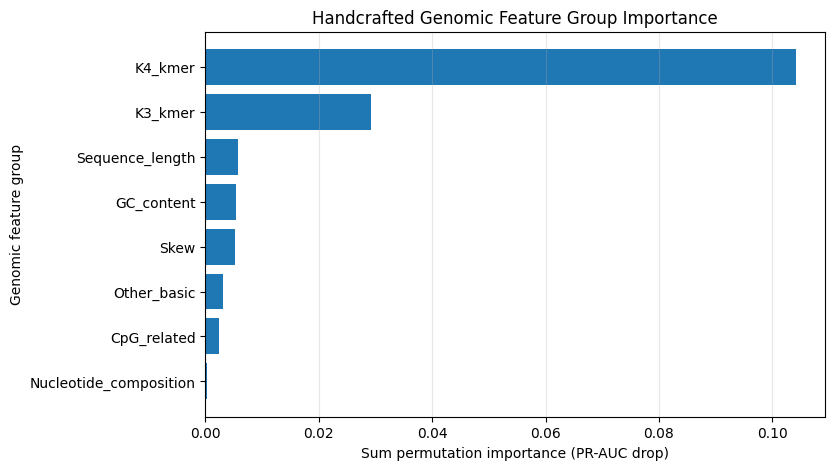

Saved: /content/drive/MyDrive/Project_Protein/model/phase14c_recover_real_genomic_feature_names/figures/phase14c_grouped_permutation_importance_final.png


In [18]:
# ============================================================
# FIGURE — GROUPED PERMUTATION IMPORTANCE
# ============================================================

plot_df = group_perm_final_df.sort_values("sum_importance", ascending=True).copy()

plt.figure(figsize=(8, 5))
plt.barh(plot_df["feature_group"], plot_df["sum_importance"])
plt.xlabel("Sum permutation importance (PR-AUC drop)")
plt.ylabel("Genomic feature group")
plt.title("Handcrafted Genomic Feature Group Importance")
plt.grid(axis="x", alpha=0.3)

out_path = FIGURE_DIR / "phase14c_grouped_permutation_importance_final.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

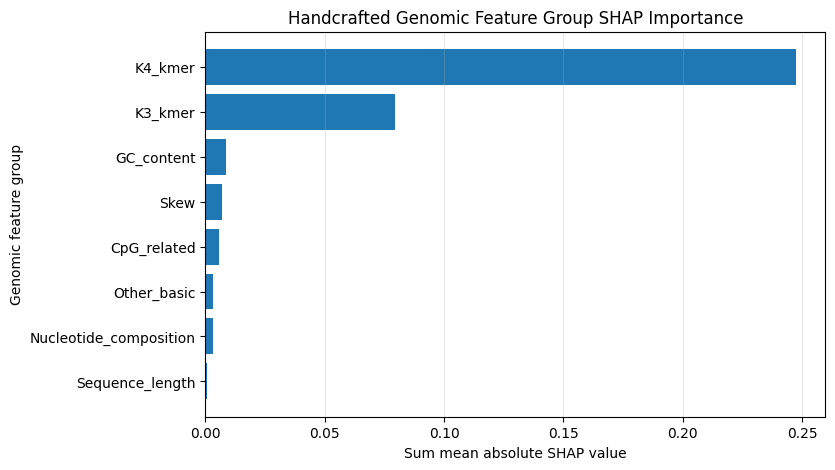

Saved: /content/drive/MyDrive/Project_Protein/model/phase14c_recover_real_genomic_feature_names/figures/phase14c_grouped_shap_importance_final.png


In [19]:
# ============================================================
# FIGURE — GROUPED SHAP IMPORTANCE
# ============================================================

if not group_shap_final_df.empty:
    plot_df = group_shap_final_df.sort_values("sum_mean_abs_shap", ascending=True).copy()

    plt.figure(figsize=(8, 5))
    plt.barh(plot_df["feature_group"], plot_df["sum_mean_abs_shap"])
    plt.xlabel("Sum mean absolute SHAP value")
    plt.ylabel("Genomic feature group")
    plt.title("Handcrafted Genomic Feature Group SHAP Importance")
    plt.grid(axis="x", alpha=0.3)

    out_path = FIGURE_DIR / "phase14c_grouped_shap_importance_final.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)
else:
    print("No SHAP grouped figure created.")

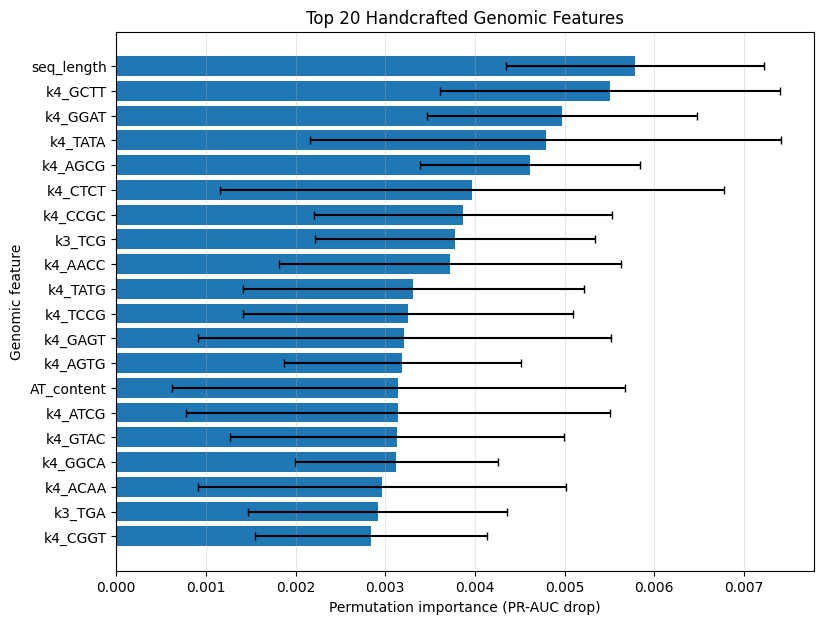

Saved: /content/drive/MyDrive/Project_Protein/model/phase14c_recover_real_genomic_feature_names/figures/phase14c_top20_permutation_features_final.png


In [20]:
# ============================================================
# FIGURE — TOP INDIVIDUAL PERMUTATION FEATURES
# ============================================================

TOP_N = 20

top_perm_plot_df = perm_mapped_df.head(TOP_N).sort_values(
    "importance_mean_pr_auc_drop",
    ascending=True
)

plt.figure(figsize=(9, 7))
plt.barh(
    top_perm_plot_df["feature_name"],
    top_perm_plot_df["importance_mean_pr_auc_drop"],
    xerr=top_perm_plot_df["importance_sd_pr_auc_drop"],
    capsize=3
)
plt.xlabel("Permutation importance (PR-AUC drop)")
plt.ylabel("Genomic feature")
plt.title(f"Top {TOP_N} Handcrafted Genomic Features")
plt.grid(axis="x", alpha=0.3)

out_path = FIGURE_DIR / "phase14c_top20_permutation_features_final.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

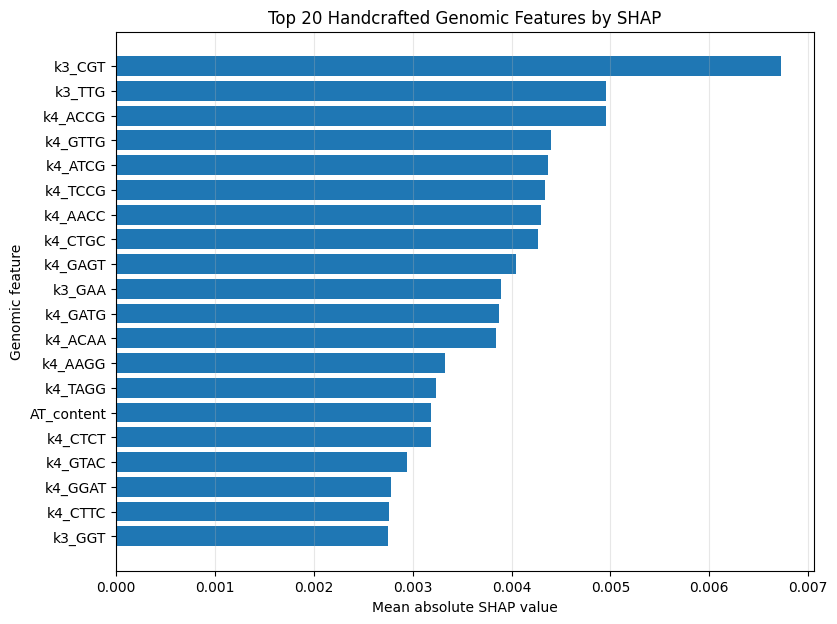

Saved: /content/drive/MyDrive/Project_Protein/model/phase14c_recover_real_genomic_feature_names/figures/phase14c_top20_shap_features_final.png


In [21]:
# ============================================================
# FIGURE — TOP INDIVIDUAL SHAP FEATURES
# ============================================================

if not shap_mapped_df.empty:
    top_shap_plot_df = shap_mapped_df.head(TOP_N).sort_values(
        "mean_abs_shap",
        ascending=True
    )

    plt.figure(figsize=(9, 7))
    plt.barh(
        top_shap_plot_df["feature_name"],
        top_shap_plot_df["mean_abs_shap"]
    )
    plt.xlabel("Mean absolute SHAP value")
    plt.ylabel("Genomic feature")
    plt.title(f"Top {TOP_N} Handcrafted Genomic Features by SHAP")
    plt.grid(axis="x", alpha=0.3)

    out_path = FIGURE_DIR / "phase14c_top20_shap_features_final.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)
else:
    print("No top SHAP feature figure created.")

In [22]:
# ============================================================
# MANUSCRIPT-READY WORDING
# ============================================================

if final_mapping_confidence == "high_saved_full_mapping":
    mapping_sentence = (
        "The original saved feature-name mapping was recovered, allowing direct grouping of handcrafted genomic features "
        "into K3 k-mers, K4 k-mers and basic sequence-composition descriptors."
    )
    cautious_sentence = (
        "Because the original feature names were recovered, feature-group interpretations were reported directly."
    )

elif final_mapping_confidence == "medium_inferred_reconstructed_order":
    mapping_sentence = (
        "A full saved feature-name mapping was not available, but the feature order was inferred using available top-feature files "
        "and the known K3/K4/Basic feature design."
    )
    cautious_sentence = (
        "Because the feature mapping was inferred, individual feature-level interpretation was treated cautiously and the main conclusions emphasized modality-level explainability."
    )

else:
    mapping_sentence = (
        "A full saved feature-name mapping was not available. Therefore, feature names were reconstructed according to the known "
        "K3/K4/Basic design of the handcrafted genomic representation."
    )
    cautious_sentence = (
        "Because the feature mapping was reconstructed rather than recovered from the original pipeline, individual feature-level interpretation was treated as exploratory."
    )

methods_text = f"""
Explainability analysis was performed at both modality and feature levels. At the modality level, block-level permutation importance was used to quantify the contribution of protein and genomic feature blocks in the multimodal models. At the feature level, a random forest explainability model was trained on the handcrafted K3/K4/Basic genomic features to enable permutation-based feature importance and SHAP analysis. {mapping_sentence} Genomic feature importance values were aggregated by feature group to summarize whether k-mer composition or basic sequence-composition descriptors contributed most strongly to the genomic explainability model. {cautious_sentence}
""".strip()

results_text = f"""
The explainability analysis provided two levels of evidence. First, modality-level permutation importance showed that the protein block produced the largest performance drops, supporting the conclusion that protein embeddings were the dominant predictive modality. The genomic block produced smaller but non-zero drops, especially for threshold-dependent metrics, indicating complementary genomic contribution. Second, feature-level permutation importance and SHAP analysis were computed for the handcrafted genomic explainability model. {mapping_sentence} The grouped feature-importance results provide exploratory evidence about which categories of handcrafted genomic sequence descriptors contributed to model behaviour.
""".strip()

discussion_text = f"""
The explainability analysis strengthens the use of the term explainable in the proposed framework. The framework does not rely solely on black-box prediction scores; it provides modality-level interpretation through block permutation, feature-level exploration for handcrafted genomic descriptors and biological validation of top-ranked genes. The results also clarify why genomic information remains valuable despite modest aggregate performance gains. Genomic features did not dominate prediction, but they contributed complementary information and offered more transparent sequence-level descriptors than latent DNABERT-2 embeddings. {cautious_sentence}
""".strip()

wording_df = pd.DataFrame([
    {"section": "Methods - Explainability Analysis", "text": methods_text},
    {"section": "Results - Explainability Analysis", "text": results_text},
    {"section": "Discussion - Explainability Interpretation", "text": discussion_text},
])

display(wording_df)

save_df(
    wording_df,
    RESULT_DIR / "phase14c_manuscript_ready_wording.csv"
)

with open(REPORT_DIR / "phase14c_manuscript_ready_wording.md", "w") as f:
    for _, row in wording_df.iterrows():
        f.write(f"## {row['section']}\n\n")
        f.write(row["text"] + "\n\n")

print("Saved manuscript wording.")

,section,text
0,Methods - Explainability Analysis,"Explainability analysis was performed at both modality and feature levels. At the modality level, block-level permutation importance was used to quantify the contribution of protein and genomic feature blocks in the multimodal models. At the feature level, a random forest explainability model was trained on the handcrafted K3/K4/Basic genomic features to enable permutation-based feature importance and SHAP analysis. A full saved feature-name mapping was not available. Therefore, feature name..."
1,Results - Explainability Analysis,"The explainability analysis provided two levels of evidence. First, modality-level permutation importance showed that the protein block produced the largest performance drops, supporting the conclusion that protein embeddings were the dominant predictive modality. The genomic block produced smaller but non-zero drops, especially for threshold-dependent metrics, indicating complementary genomic contribution. Second, feature-level permutation importance and SHAP analysis were computed for the ..."
2,Discussion - Explainability Interpretation,"The explainability analysis strengthens the use of the term explainable in the proposed framework. The framework does not rely solely on black-box prediction scores; it provides modality-level interpretation through block permutation, feature-level exploration for handcrafted genomic descriptors and biological validation of top-ranked genes. The results also clarify why genomic information remains valuable despite modest aggregate performance gains. Genomic features did not dominate predicti..."


Saved: /content/drive/MyDrive/Project_Protein/model/phase14c_recover_real_genomic_feature_names/results/phase14c_manuscript_ready_wording.csv
Saved manuscript wording.


In [23]:
# ============================================================
# EXPORT EXCEL WORKBOOK
# ============================================================

excel_path = EXCEL_DIR / "phase14c_recovered_feature_mapping_and_explainability.xlsx"

tables = {
    "Text_Candidates": deep_text_candidates_df,
    "CSV_Candidates": csv_feature_candidates_df,
    "Binary_Candidates": binary_feature_candidates_df,
    "Combined_Candidates": combined_feature_candidates_df,
    "Top_Feature_Clues": top_feature_clues_df,
    "Order_Inference": order_inference_df,
    "Final_Mapping": final_feature_info_df,
    "Permutation_Mapped": perm_mapped_df,
    "Group_Permutation": group_perm_final_df,
    "Claims": claims_df,
    "Wording": wording_df,
}

if not shap_mapped_df.empty:
    tables["SHAP_Mapped"] = shap_mapped_df
    tables["Group_SHAP"] = group_shap_final_df

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet_name, df in tables.items():
        if df is not None and not df.empty:
            df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print("Saved Excel:", excel_path)

Saved Excel: /content/drive/MyDrive/Project_Protein/model/phase14c_recover_real_genomic_feature_names/excel/phase14c_recovered_feature_mapping_and_explainability.xlsx


In [24]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("=== PHASE 14C COMPLETE ===")
print("Final mapping source:", final_mapping_source)
print("Final mapping confidence:", final_mapping_confidence)

print("\nFeature group counts:")
display(final_feature_info_df["feature_group"].value_counts())

print("\nGrouped permutation importance:")
display(group_perm_final_df)

if not group_shap_final_df.empty:
    print("\nGrouped SHAP importance:")
    display(group_shap_final_df)

print("\nTop mapped permutation features:")
display(perm_mapped_df.head(20))

if not shap_mapped_df.empty:
    print("\nTop mapped SHAP features:")
    display(shap_mapped_df.head(20))

print("\nClaims:")
display(claims_df)

print("\nWording:")
display(wording_df)

print("\nResult files:")
for p in sorted(RESULT_DIR.glob("*")):
    print(p)

print("\nFigures:")
for p in sorted(FIGURE_DIR.glob("*")):
    print(p)

print("\nExcel:")
for p in sorted(EXCEL_DIR.glob("*")):
    print(p)

=== PHASE 14C COMPLETE ===
Final mapping source: reconstructed_order_default_assumption::K3_K4_Basic
Final mapping confidence: low_assumed_reconstructed_order

Feature group counts:


,count
feature_group,
K4_kmer,256
K3_kmer,64
GC_content,14
CpG_related,9
Skew,7
Nucleotide_composition,4
Sequence_length,1
Other_basic,1



Grouped permutation importance:


,feature_group,n_features,sum_importance,mean_importance,max_importance,relative_group_importance,mapping_confidence,mapping_source
0,K4_kmer,256,0.104116,0.000407,0.005506,0.668589,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
1,K3_kmer,64,0.029172,0.000456,0.003782,0.187330,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
2,Sequence_length,1,0.005790,0.005790,0.005790,0.037181,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
3,GC_content,14,0.005437,0.000388,0.002736,0.034914,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
4,Skew,7,0.005317,0.000760,0.002588,0.034144,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
5,Other_basic,1,0.003148,0.003148,0.003148,0.020215,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
6,CpG_related,9,0.002367,0.000263,0.001739,0.015200,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
7,Nucleotide_composition,4,0.000378,0.000095,0.000461,0.002427,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic



Grouped SHAP importance:


...


Claims:


,analysis,finding,interpretation,caution_level,caution
0,Grouped permutation importance,"Top group by PR-AUC permutation importance: K4_kmer (sum importance = 0.1041, relative = 0.6686).",This summarizes which handcrafted genomic feature type contributed most to the genomic RF explainability model.,high,A full original feature-name mapping was not found. Feature names were reconstructed based on the known K3/K4/Basic design; individual feature-level interpretation should be treated as exploratory.
1,Grouped SHAP importance,Top group by mean absolute SHAP: K4_kmer (relative SHAP = 0.6967).,This provides SHAP-based feature-group explanation for the handcrafted genomic RF explainability model.,high,A full original feature-name mapping was not found. Feature names were reconstructed based on the known K3/K4/Basic design; individual feature-level interpretation should be treated as exploratory.
2,Top individual permutation features,Top 10 features: seq_length; k4_GCTT; k4_GGAT; k4_TATA; k4_AGCG; k4_CTCT; k4_CCGC; k3_TCG; k4_AACC; k4_TATG,These features produced the largest PR-AUC drops when permuted.,high,A full original feature-name mapping was not found. Feature names were reconstructed based on the known K3/K4/Basic design; individual feature-level interpretation should be treated as exploratory.
3,Top individual SHAP features,Top 10 features: k3_CGT; k3_TTG; k4_ACCG; k4_GTTG; k4_ATCG; k4_TCCG; k4_AACC; k4_CTGC; k4_GAGT; k3_GAA,These features had the largest mean absolute SHAP values.,high,A full original feature-name mapping was not found. Feature names were reconstructed based on the known K3/K4/Basic design; individual feature-level interpretation should be treated as exploratory.



Wording:


,section,text
0,Methods - Explainability Analysis,"Explainability analysis was performed at both modality and feature levels. At the modality level, block-level permutation importance was used to quantify the contribution of protein and genomic feature blocks in the multimodal models. At the feature level, a random forest explainability model was trained on the handcrafted K3/K4/Basic genomic features to enable permutation-based feature importance and SHAP analysis. A full saved feature-name mapping was not available. Therefore, feature name..."
1,Results - Explainability Analysis,"The explainability analysis provided two levels of evidence. First, modality-level permutation importance showed that the protein block produced the largest performance drops, supporting the conclusion that protein embeddings were the dominant predictive modality. The genomic block produced smaller but non-zero drops, especially for threshold-dependent metrics, indicating complementary genomic contribution. Second, feature-level permutation importance and SHAP analysis were computed for the ..."
2,Discussion - Explainability Interpretation,"The explainability analysis strengthens the use of the term explainable in the proposed framework. The framework does not rely solely on black-box prediction scores; it provides modality-level interpretation through block permutation, feature-level exploration for handcrafted genomic descriptors and biological validation of top-ranked genes. The results also clarify why genomic information remains valuable despite modest aggregate performance gains. Genomic features did not dominate predicti..."



Result files:
/content/drive/MyDrive/Project_Protein/model/phase14c_recover_real_genomic_feature_names/results/phase14c_binary_feature_name_candidates.csv
/content/drive/MyDrive/Project_Protein/model/phase14c_recover_real_genomic_feature_names/results/phase14c_combined_feature_name_candidates.csv
/content/drive/MyDrive/Project_Protein/model/phase14c_recover_real_genomic_feature_names/results/phase14c_csv_feature_name_candidates.csv
/content/drive/MyDrive/Project_Protein/model/phase14c_recover_real_genomic_feature_names/results/phase14c_deep_text_feature_name_candidates.csv
/content/drive/MyDrive/Project_Protein/model/phase14c_recover_real_genomic_feature_names/results/phase14c_final_genomic_feature_mapping.csv
/content/drive/MyDrive/Project_Protein/model/phase14c_recover_real_genomic_feature_names/results/phase14c_grouped_permutation_importance_final.csv
/content/drive/MyDrive/Project_Protein/model/phase14c_recover_real_genomic_feature_names/results/phase14c_grouped_shap_importance_fi

In [25]:
display(combined_feature_candidates_df.head(30))
display(top_feature_clues_df)
display(order_inference_df)
display(final_feature_info_df["feature_group"].value_counts())
display(group_perm_final_df)

if not group_shap_final_df.empty:
    display(group_shap_final_df)

display(perm_mapped_df.head(30))

if not shap_mapped_df.empty:
    display(shap_mapped_df.head(30))

display(claims_df)
display(wording_df)

,candidate_id,source_type,path,column_or_key,n_names,n_generic,n_real_like,real_like_ratio,generic_ratio,is_full_356_real,groups,preview
0,2,csv_column,/content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_2_error_modality_contribution/results/phase3_2C_combined_logistic_regression_coefficients.csv,feature,1379,0,344,0.249456,0.0,False,"{""Other_basic"": 1036, ""K4_kmer"": 256, ""K3_kmer"": 64, ""GC_content"": 16, ""CpG_related"": 6, ""Skew"": 1}",k4_GTAG; protbert_sw_40; protbert_sw_418; protbert_sw_822; k4_GGTA; k4_ACCA; k4_TCTG; protbert_sw_160; protbert_sw_976; protbert_sw_763; protbert_sw_555; k4_CTGT; k4_CCGA; k4_CCAT; protbert_sw_327
1,10,csv_column,/content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_all_expanded_enrichment_results.csv,name,811,0,53,0.065351,0.0,False,"{""Other_basic"": 810, ""CpG_related"": 1}","NADH dehydrogenase (ubiquinone) activity; respiratory chain complex I; NADH dehydrogenase complex; Mitochondrial complex I assembly model OXPHOS system; Electron transport chain OXPHOS system in mitochondria; respiratory electron transport chain; Impaired glucose tolerance; Respiratory electron transport; Insulin resistance; Insulin secretion; mitochondrial electron transport, NADH to ubiquinone; proton motive force-driven mitochondrial ATP synthesis; Complex I biogenesis; proton motive forc..."
2,0,csv_column,/content/drive/MyDrive/Project_Protein/model/phase2_2_genomic_analysis/results/phase2_2_random_forest_feature_importance.csv,feature,355,0,344,0.969014,0.0,False,"{""K4_kmer"": 256, ""K3_kmer"": 64, ""GC_content"": 16, ""Other_basic"": 12, ""CpG_related"": 6, ""Skew"": 1}",k4_TGAG; k4_AAGG; k4_CCCC; GC_content_bin_08; k4_CTGT; k4_CGCT; k3_TAG; k4_GATC; k4_AGTG; k4_CTTT; k4_GTAG; k4_CTCC; k4_TCAG; k4_CTCA; k3_GTA
3,1,csv_column,/content/drive/MyDrive/Project_Protein/model/phase2_2_genomic_analysis/results/phase2_2_logistic_regression_coefficients.csv,feature,355,0,344,0.969014,0.0,False,"{""K4_kmer"": 256, ""K3_kmer"": 64, ""GC_content"": 16, ""Other_basic"": 12, ""CpG_related"": 6, ""Skew"": 1}",k4_CTGT; k4_CCGT; k4_ATCC; k4_AAGG; k4_GATC; k4_GTAG; k4_AAAG; k4_TGAG; k4_AACC; k4_TCTG; k4_TAGG; k4_ATGG; k4_TGAC; k4_GGTA; k4_CTCC
4,9,csv_column,/content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/enrichment_results/gprofiler_enrichment_Protein_only_ProtBERT_SW_top100.csv,name,106,0,9,0.084906,0.0,False,"{""Other_basic"": 105, ""CpG_related"": 1}","NADH dehydrogenase (ubiquinone) activity; respiratory chain complex I; NADH dehydrogenase complex; Mitochondrial complex I assembly model OXPHOS system; Electron transport chain OXPHOS system in mitochondria; respiratory electron transport chain; Impaired glucose tolerance; Respiratory electron transport; Insulin resistance; Insulin secretion; mitochondrial electron transport, NADH to ubiquinone; proton motive force-driven mitochondrial ATP synthesis; Complex I biogenesis; proton motive forc..."
5,3,csv_column,/content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_2_error_modality_contribution/results/phase3_2C_top_genomic_features_combined_lr.csv,feature,50,0,50,1.000000,0.0,False,"{""K4_kmer"": 45, ""K3_kmer"": 4, ""GC_content"": 1}",k4_GTAG; k4_GGTA; k4_ACCA; k4_TCTG; k4_CTGT; k4_CCGA; k4_CCAT; k4_TGAC; k4_ATCC; k4_CGAC; k4_GGTT; k4_GATC; k4_CTTT; k4_CAAG; k4_GAGA
6,4,csv_column,/content/drive/MyDrive/Project_Protein/model/phase2_genomic_regulatory_baseline/results/phase2_1_genomic_feature_ablation_5fold_cv_v1.csv,feature_set,20,0,4,0.200000,0.0,False,"{""Other_basic"": 16, ""CpG_related"": 4}",K3 + K4 + K5 + Basic; K3 + K4 + K5 + Basic; K3 + K4 + Basic; K4 + Basic; K3 + K4 + K5 + Basic; K4 + Basic; K4 + Basic; K3 + K4 + Basic; K3 + K4 + Basic; K3 + Basic; K3 + Basic; K3 + Basic; Basic GC/CpG/skew/bins; K3 + Basic; Basic GC/CpG/skew/bins
7,5,csv_column,/content/drive/MyDrive/Project_Protein/model/phase14b_fix_genomic_feature_mapping/

,path,shape,column_used,columns,n_names,n_real_like,groups,preview
0,/content/drive/MyDrive/Project_Protein/model/phase3_multimodal_integration/phase3_2_error_modality_contribution/results/phase3_2C_top_genomic_features_combined_lr.csv,"(50, 4)",feature,feature; coefficient; abs_coefficient; modality,50,50,"{""K4_kmer"": 45, ""K3_kmer"": 4, ""GC_content"": 1}",k4_GTAG; k4_GGTA; k4_ACCA; k4_TCTG; k4_CTGT; k4_CCGA; k4_CCAT; k4_TGAC; k4_ATCC; k4_CGAC; k4_GGTT; k4_GATC; k4_CTTT; k4_CAAG; k4_GAGA


""


,count
feature_group,
K4_kmer,256
K3_kmer,64
GC_content,14
CpG_related,9
Skew,7
Nucleotide_composition,4
Sequence_length,1
Other_basic,1


,feature_group,n_features,sum_importance,mean_importance,max_importance,relative_group_importance,mapping_confidence,mapping_source
0,K4_kmer,256,0.104116,0.000407,0.005506,0.668589,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
1,K3_kmer,64,0.029172,0.000456,0.003782,0.187330,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
2,Sequence_length,1,0.005790,0.005790,0.005790,0.037181,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
3,GC_content,14,0.005437,0.000388,0.002736,0.034914,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
4,Skew,7,0.005317,0.000760,0.002588,0.034144,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
5,Other_basic,1,0.003148,0.003148,0.003148,0.020215,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
6,CpG_related,9,0.002367,0.000263,0.001739,0.015200,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
7,Nucleotide_composition,4,0.000378,0.000095,0.000461,0.002427,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic


,feature_group,n_features,sum_mean_abs_shap,mean_abs_shap,max_abs_shap,relative_group_shap_importance,mapping_confidence,mapping_source
0,K4_kmer,256,0.247288,0.000966,0.004953,0.696674,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
1,K3_kmer,64,0.079391,0.001240,0.006722,0.223665,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
2,GC_content,14,0.008842,0.000632,0.001456,0.024910,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
3,Skew,7,0.006942,0.000992,0.002027,0.019558,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
4,CpG_related,9,0.005561,0.000618,0.001160,0.015667,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
5,Other_basic,1,0.003182,0.003182,0.003182,0.008966,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
6,Nucleotide_composition,4,0.003028,0.000757,0.001668,0.008531,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic
7,Sequence_length,1,0.000721,0.000721,0.000721,0.002031,low_assumed_reconstructed_order,reconstructed_order_default_assumption::K3_K4_Basic


,feature_index,old_feature_name,old_feature_group,importance_mean_pr_auc_drop,importance_sd_pr_auc_drop,feature_name,feature_group,mapping_source,mapping_confidence
0,320,genomic_feature_320,Other_basic,0.005790,0.001438,seq_length,Sequence_length,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
1,223,genomic_feature_223,Other_basic,0.005506,0.001896,k4_GCTT,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
2,227,genomic_feature_227,Other_basic,0.004972,0.001508,k4_GGAT,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
3,268,genomic_feature_268,Other_basic,0.004788,0.002622,k4_TATA,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
4,102,genomic_feature_102,Other_basic,0.004619,0.001228,k4_AGCG,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
5,183,genomic_feature_183,Other_basic,0.003970,0.002812,k4_CTCT,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
6,153,genomic_feature_153,Other_basic,0.003866,0.001666,k4_CCGC,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
7,54,genomic_feature_54,Other_basic,0.003782,0.001563,k3_TCG,K3_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
8,69,genomic_feature_69,Other_basic,0.003719,0.001908,k4_AACC,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
9,270,genomic_feature_270,Other_basic,0.003311,0.001901,k4_TATG,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order


,feature_index,old_feature_name,old_feature_group,mean_abs_shap,feature_name,feature_group,mapping_source,mapping_confidence
0,27,genomic_feature_27,Other_basic,0.006722,k3_CGT,K3_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
1,62,genomic_feature_62,Other_basic,0.004957,k3_TTG,K3_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
2,86,genomic_feature_86,Other_basic,0.004953,k4_ACCG,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
3,254,genomic_feature_254,Other_basic,0.004394,k4_GTTG,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
4,118,genomic_feature_118,Other_basic,0.004373,k4_ATCG,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
5,278,genomic_feature_278,Other_basic,0.004334,k4_TCCG,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
6,69,genomic_feature_69,Other_basic,0.004297,k4_AACC,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
7,185,genomic_feature_185,Other_basic,0.004262,k4_CTGC,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
8,203,genomic_feature_203,Other_basic,0.004047,k4_GAGT,K4_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order
9,32,genomic_feature_32,Other_basic,0.003898,k3_GAA,K3_kmer,reconstructed_order_default_assumption::K3_K4_Basic,low_assumed_reconstructed_order


,analysis,finding,interpretation,caution_level,caution
0,Grouped permutation importance,"Top group by PR-AUC permutation importance: K4_kmer (sum importance = 0.1041, relative = 0.6686).",This summarizes which handcrafted genomic feature type contributed most to the genomic RF explainability model.,high,A full original feature-name mapping was not found. Feature names were reconstructed based on the known K3/K4/Basic design; individual feature-level interpretation should be treated as exploratory.
1,Grouped SHAP importance,Top group by mean absolute SHAP: K4_kmer (relative SHAP = 0.6967).,This provides SHAP-based feature-group explanation for the handcrafted genomic RF explainability model.,high,A full original feature-name mapping was not found. Feature names were reconstructed based on the known K3/K4/Basic design; individual feature-level interpretation should be treated as exploratory.
2,Top individual permutation features,Top 10 features: seq_length; k4_GCTT; k4_GGAT; k4_TATA; k4_AGCG; k4_CTCT; k4_CCGC; k3_TCG; k4_AACC; k4_TATG,These features produced the largest PR-AUC drops when permuted.,high,A full original feature-name mapping was not found. Feature names were reconstructed based on the known K3/K4/Basic design; individual feature-level interpretation should be treated as exploratory.
3,Top individual SHAP features,Top 10 features: k3_CGT; k3_TTG; k4_ACCG; k4_GTTG; k4_ATCG; k4_TCCG; k4_AACC; k4_CTGC; k4_GAGT; k3_GAA,These features had the largest mean absolute SHAP values.,high,A full original feature-name mapping was not found. Feature names were reconstructed based on the known K3/K4/Basic design; individual feature-level interpretation should be treated as exploratory.


,section,text
0,Methods - Explainability Analysis,"Explainability analysis was performed at both modality and feature levels. At the modality level, block-level permutation importance was used to quantify the contribution of protein and genomic feature blocks in the multimodal models. At the feature level, a random forest explainability model was trained on the handcrafted K3/K4/Basic genomic features to enable permutation-based feature importance and SHAP analysis. A full saved feature-name mapping was not available. Therefore, feature name..."
1,Results - Explainability Analysis,"The explainability analysis provided two levels of evidence. First, modality-level permutation importance showed that the protein block produced the largest performance drops, supporting the conclusion that protein embeddings were the dominant predictive modality. The genomic block produced smaller but non-zero drops, especially for threshold-dependent metrics, indicating complementary genomic contribution. Second, feature-level permutation importance and SHAP analysis were computed for the ..."
2,Discussion - Explainability Interpretation,"The explainability analysis strengthens the use of the term explainable in the proposed framework. The framework does not rely solely on black-box prediction scores; it provides modality-level interpretation through block permutation, feature-level exploration for handcrafted genomic descriptors and biological validation of top-ranked genes. The results also clarify why genomic information remains valuable despite modest aggregate performance gains. Genomic features did not dominate predicti..."


In [26]:
print("Final mapping confidence:", final_mapping_confidence)

Final mapping confidence: low_assumed_reconstructed_order
